"""# 4- choosing a neural network architecture :

#- 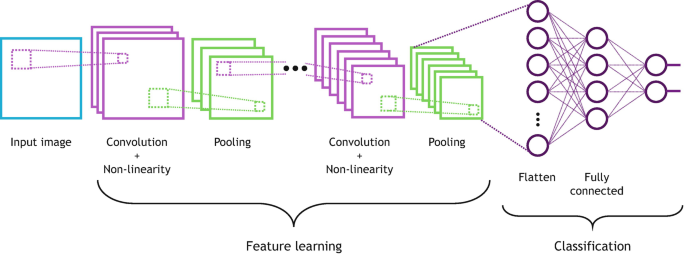
"""

In [ ]:
# -*- coding: utf-8 -*-
"""pneumonia-detector-using-deeplearning.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/11Qnd7eqeRLIRCFLJsNzzbPK1ryL8sCgT

# 1- Packages :
"""

# Commented out IPython magic to ensure Python compatibility.
import os
import numpy as np
import pandas as pd
import random
import cv2
import glob
import matplotlib.pyplot as plt
# %matplotlib inline
from google.colab import drive
from PIL import Image as mpimg
import matplotlib.image as mpimg
drive.mount('/content/drive')
import keras.backend as K
from keras.models import Model, Sequential
from keras.layers import Input, Dense, Flatten, Dropout, BatchNormalization
from keras.layers import Conv2D, SeparableConv2D, MaxPool2D, LeakyReLU, Activation
from keras.optimizers import Adam
np.random.seed(232)
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import tensorflow as tf
import seaborn as sns
tf.random.set_seed(232)

"""# 2- Data Exploration :

# 2.1 Building the path to the project directories  :
"""

cwd = os.getcwd()
main_file_path = os.path.join(cwd, 'Notebook.ipynb')


colab_notebooks_path = '/content/drive/My Drive/Colab Notebooks/pneumonia-detector'

os.chdir(colab_notebooks_path)

input_path = '/content/drive/My Drive/chest_xray'

train_path = os.path.join(input_path, 'train')
test_path = os.path.join(input_path, 'test')
val_path = os.path.join(input_path, 'val')

"""# 2.2 Visualization of some images from the dataset :"""

import os
import matplotlib.pyplot as plt

input_path = '/content/drive/My Drive/chest_xray'

nows = 2
ncols = 6

train_path = input_path + '/train/NORMAL'


files = os.listdir(train_path)
rand_images = random.sample(files,nows*ncols)

fig = plt.gcf()
fig.set_size_inches(ncols*2, nows*2)


for i in range(len(rand_images)):
    sp = plt.subplot(nows, ncols, i + 1)
    plt.title("Normale")
    sp.axis('Off')

    img = mpimg.imread(train_path + '/' + rand_images[i])
    plt.imshow(img,cmap='gray')

plt.show()

"""# 2.3 Visualization of some abnormal images from the dataset :"""

nows = 2
ncols = 6

train_path = input_path + '/train/PNEUMONIA'


files = os.listdir(train_path)
rand_images = random.sample(files,nows*ncols)

fig = plt.gcf()
fig.set_size_inches(ncols*2, nows*2)


for i in range(len(rand_images)):
    sp = plt.subplot(nows, ncols, i + 1)
    plt.title("Pneumonia")
    sp.axis('Off')

    img = mpimg.imread(train_path + '/' + rand_images[i])
    plt.imshow(img,cmap='gray')

plt.show()

"""# 2.4- View directories information :"""

print("Le nombre d'images normales dans le répertoire train est: ",len(os.listdir(input_path + "/train/NORMAL")))
print("Le nombre d'images anormales dans le répertoire train est: ", len(os.listdir(input_path + "/train/PNEUMONIA")))

print("le nombre d'images normales dans le répertoire test est: ",len(os.listdir(input_path + "/test/NORMAL")))
print("Le nombre d’images anormales dans le répertoire test est: ",len(os.listdir(input_path + "/test/PNEUMONIA")))

print("Le nombre d'images normales dans le répertoire val est: ",len(os.listdir(input_path + "/val/NORMAL")))
print("Le nombre d’images anormales dans le répertoire val est: ",len(os.listdir(input_path + "/val/PNEUMONIA")))

"""# 2.5- Visualizing data as graphs :"""

def plotData(dirPath):
    normal_dir = os.path.join(dirPath, 'NORMAL')
    pneumonia_dir = os.path.join(dirPath, 'PNEUMONIA')

    # Vérifiez si les répertoires existent et contiennent des fichiers :
    if not os.path.exists(normal_dir) or not os.path.exists(pneumonia_dir):
        print("Error: Directories not found or empty.")
        return

    # Obtenez la liste de toutes les images :
    normal_cases = glob.glob(normal_dir + '/*.jpeg')
    pneumonia_cases = glob.glob(pneumonia_dir + '/*.jpeg')

    # Vérifiez s'il y a des images dans les deux répertoires :
    if not normal_cases or not pneumonia_cases:
        print("Error: No images found in one or both directories.")
        return

    # Une liste vide. Nous insérerons les données dans cette liste au format (img_path, label)
    data = []

    # Parcourez tous les cas normaux. L'étiquette de ces cas sera 0 :
    for img in normal_cases:
        data.append((img, 0))

    # Parcourez tous les cas de pneumonie. L'étiquette de ces cas sera 1
    for img in pneumonia_cases:
        data.append((img, 1))

    # Obtenez une trame de données pandas à partir des données que nous avons dans notre liste
    df = pd.DataFrame(data, columns=['image', 'label'])

    # Mélangez les données
    df = df.sample(frac=1.).reset_index(drop=True)

    # Obtenez les décomptes pour chaque classe
    cases_count = df['label'].value_counts()

    # Tracez les résultats
    plt.figure(figsize=(8,8))
    sns.barplot(x=cases_count.index, y=cases_count.values, palette=["gray", "orange"])
    plt.title('Number of cases', fontsize=12)
    plt.xlabel('Case type', fontsize=10)
    plt.ylabel('Count', fontsize=10)
    plt.xticks(range(len(cases_count.index)), ['NORMAL', 'PNEUMONIA'])
    plt.show()

"""#2.6- voir le graphique des données d'entrainement :"""

# Appel de la fonction avec le chemin du répertoire d'entraînement :
input_path = '/content/drive/My Drive/chest_xray'
train_path = os.path.join(input_path, 'train')

plotData(train_path)

"""#2.7- voir le graphique des données de test :"""

plotData(test_path)

"""#2.8- voir le graphique des données de validation :"""

plotData(val_path)

# 3- Data preprocessing :

In [ ]:
def process_data(img_dims, batch_size, train_path, test_path):
    # Data generation objects
    train_datagen = ImageDataGenerator(
        rescale=1./255, zoom_range=0.3, vertical_flip=True
        )   #
    test_val_datagen = ImageDataGenerator(rescale=1./255)

    # This is fed to the network in the specified batch sizes and image dimensions
    train_gen = train_datagen.flow_from_directory(
        train_path,
        target_size=(img_dims, img_dims),
        batch_size=batch_size,
        class_mode='binary',
        shuffle=True)

    test_gen = test_val_datagen.flow_from_directory(
        test_path,
        target_size=(img_dims, img_dims),
        batch_size=batch_size,
        class_mode='binary',
        shuffle=True)


    test_data = []
    test_labels = []

    for cond in ['/NORMAL/', '/PNEUMONIA/']:
        for img in os.listdir(test_path + cond):
            img = plt.imread(test_path + cond + img)
            img = cv2.resize(img, (img_dims, img_dims))
            img = np.dstack([img, img, img])
            img = img.astype('float32') / 255
            if cond == '/NORMAL/':
                label = 0
            elif cond == '/PNEUMONIA/':
                label = 1
            test_data.append(img)
            test_labels.append(label)

    test_data = np.array(test_data)
    test_labels = np.array(test_labels)

    return train_gen, test_gen, test_data, test_labels

In [ ]:
img_dims = 150
epochs = 10
batch_size = 32

train_path = '/content/drive/My Drive/chest_xray/train/'
test_path = '/content/drive/My Drive/chest_xray/test/'

train_gen, test_gen, test_data, test_labels = process_data(img_dims, batch_size, train_path, test_path)

"""# 4- choosing a neural network architecture :

#- 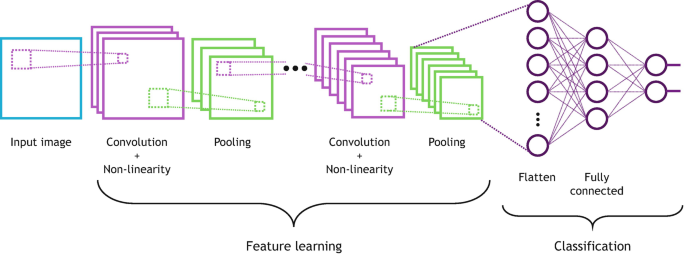
"""

In [ ]:
inputs = Input(shape=(img_dims, img_dims, 3))

# prémiere couche convolutionnelle :
x = Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = MaxPool2D(pool_size=(2, 2))(x)

# Seconde couche convolutionnelle séparable :
x = SeparableConv2D(32, (3, 3), activation='relu', padding='same')(x)
x = SeparableConv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPool2D(pool_size=(2, 2))(x)

# Troisiéme couche convolutionnelle séparable :
x = SeparableConv2D(64, (3, 3), activation='relu', padding='same')(x)
x = SeparableConv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPool2D(pool_size=(2, 2))(x)

# quatriéme couche convolutionnelle séparable :
x = SeparableConv2D(128, (3, 3), activation='relu', padding='same')(x)
x = SeparableConv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPool2D(pool_size=(2, 2))(x)
x = Dropout(rate=0.2)(x)

# Cinquiéme couche convolutionnelle séparable :
x = SeparableConv2D(256, (3, 3), activation='relu', padding='same')(x)
x = SeparableConv2D(256, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPool2D(pool_size=(2, 2))(x)
x = Dropout(rate=0.2)(x)

# couche entiérement connectée :
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(rate=0.7)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(rate=0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(rate=0.3)(x)

# couche de sortie :
output = Dense(1, activation='sigmoid')(x)

In [ ]:
"""# 4.1- Creation and compilation of the model :

"""

model = Model(inputs=inputs, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
"""# 4.2- Displaying the model summary :"""

model.summary()

# Callbacks: les rappels
checkpoint = ModelCheckpoint(filepath='/content/drive/My Drive/project/best_weights.hdf5', save_best_only=True, save_weights_only=True)
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, verbose=2, mode='max')
early_stop = EarlyStopping(monitor='val_loss', min_delta=0.1, patience=1, mode='min')

In [ ]:
"""# 5- Model training :"""

hist = model.fit_generator(
           train_gen, steps_per_epoch=train_gen.samples // batch_size,
           epochs=epochs, validation_data=test_gen,
           validation_steps=test_gen.samples // batch_size, callbacks=[checkpoint, lr_reduce])

In [ ]:
"""# 6- model evaluation :"""

# Charger les poids optimaux
model.load_weights('/content/drive/My Drive/project/best_weights.hdf5')

# Évaluation sur l'ensemble de test
evaluation = model.evaluate(test_data, test_labels)

# Afficher les résultats de l'évaluation
print("Loss:", evaluation[0])
print("Accuracy:", evaluation[1])

In [ ]:
"""# 7- Visualizing the results :  """

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax = ax.ravel()

for i, met in enumerate(['accuracy', 'loss']):
    ax[i].plot(hist.history[met])
    ax[i].plot(hist.history['val_' + met])
    ax[i].set_title('Model {}'.format(met))
    ax[i].set_xlabel('epochs')
    ax[i].set_ylabel(met)
    ax[i].legend(['train', 'val'])

In [ ]:
"""# 8- Prediction and calculation of precision, recall and F1-score then display of the confusion matrix :"""

from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Calcul des prédictions du modèle sur les données de test
preds = model.predict(test_data)

# Calcul de l'exactitude (accuracy)
acc = accuracy_score(test_labels, np.round(preds)) * 100

# Calcul de la matrice de confusion
cm = confusion_matrix(test_labels, np.round(preds))
tn, fp, fn, tp = cm.ravel()

print('CONFUSION MATRIX ------------------')
print(cm)

# Définition des étiquettes des axes
labels = ['True Negative', 'False Positive', 'False Negative', 'True Positive']

# Conversion de la matrice en pourcentages pour une meilleure visualisation
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Configuration de la figure
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)  # Ajuster la taille de la police
sns.heatmap(cm_percent, annot=True, fmt=".2%", cmap="Blues", xticklabels=labels, yticklabels=labels)

# Ajout de titres et d'étiquettes
plt.title('Matrice de Confusion Normalisée')
plt.xlabel('Valeurs Prédites')
plt.ylabel('Valeurs Réelles')
plt.show()

In [ ]:
# Calcul de la sensibilité (recall)
sensitivity = recall_score(test_labels, np.round(preds)) * 100

# Calcul de la spécificité
specificity = (tn / (tn + fp)) * 100

print("Sensibilité: {:.4f}".format(sensitivity))
print("Spécificité: {:.4f}".format(specificity))

print('\nTEST METRICS ----------------------')

# Calcul de la précision
precision = precision_score(test_labels, np.round(preds)) * 100

# Calcul du rappel (recall)
recall = tp / (tp + fn) * 100

# Calcul du score F1
f1_score = 2 * precision * recall / (precision + recall)

print('Exactitude: {}%'.format(acc))
print('Précision: {}%'.format(precision))
print('Rappel: {}%'.format(recall))
print('Score F1: {}'.format(f1_score))

print('\nTRAIN METRIC ----------------------')

In [ ]:
"""# 9- Classification report :"""

from sklearn.metrics import classification_report

# Génération du rapport de classification
class_report = classification_report(test_labels, np.round(preds), target_names=['NORMAL', 'PNEUMONIA'])

# Affichage du rapport de classification
print("Rapport de Classification :\n", class_report)

In [ ]:
"""# 10- Saving the model :"""

# Définir le chemin de sauvegarde du modèle
model_save_path = '/content/drive/My Drive/test.h5'

# Sauvegarder le modèle
model.save(model_save_path)

print("Le modèle a été sauvegardé avec succès à l'emplacement :", model_save_path)